In [2]:
# Cell 1: Import required libraries
import os
import shutil
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [3]:
# Cell 2: Set project folder path (Windows path for Assignment 6)
PROJECT_DIR = pathlib.Path(r"C:\Users\adity\OneDrive\Desktop\Assignment 6")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working directory set to:", os.getcwd())


Working directory set to: C:\Users\adity\OneDrive\Desktop\Assignment 6


In [8]:
# Cell 3: Download small flowers dataset (built-in Keras utility, no Kaggle login needed)
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
downloaded_path = tf.keras.utils.get_file(
    fname="flower_photos",
    origin=dataset_url,
    untar=True,
    cache_dir=str(PROJECT_DIR),
    cache_subdir="dataset_raw"
)

# get_file's returned path can sometimes point one level above the actual
# class folders depending on TF version, so we search for it explicitly.
search_root = PROJECT_DIR / "dataset_raw"
matches = [p.parent for p in search_root.rglob("daisy") if p.is_dir()]

if not matches:
    raise FileNotFoundError(
        "Could not locate the flower_photos class folders after download/extraction. "
        f"Check contents of: {search_root}"
    )

data_dir = matches[0]
print("Dataset resolved at:", data_dir)
print("Classes found:", [d.name for d in data_dir.iterdir() if d.is_dir()])

Dataset resolved at: C:\Users\adity\OneDrive\Desktop\Assignment 6\dataset_raw\flower_photos\flower_photos
Classes found: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [9]:
# Cell 4: Build a SMALL subset (few images per class) inside our project folder
small_dataset_dir = PROJECT_DIR / "dataset" / "train"
IMAGES_PER_CLASS = 40   # small dataset size, keeps training fast

if small_dataset_dir.exists():
    shutil.rmtree(small_dataset_dir)
small_dataset_dir.mkdir(parents=True, exist_ok=True)

classes = [d.name for d in data_dir.iterdir() if d.is_dir()]

for cls in classes:
    src_folder = data_dir / cls
    dst_folder = small_dataset_dir / cls
    dst_folder.mkdir(parents=True, exist_ok=True)
    images = list(src_folder.glob("*.jpg"))[:IMAGES_PER_CLASS]
    for img_path in images:
        shutil.copy(img_path, dst_folder / img_path.name)

print("Small dataset created at:", small_dataset_dir.resolve())
for cls in classes:
    n = len(list((small_dataset_dir / cls).glob('*.jpg')))
    print(f"  {cls}: {n} images")


Small dataset created at: C:\Users\adity\OneDrive\Desktop\Assignment 6\dataset\train
  daisy: 40 images
  dandelion: 40 images
  roses: 40 images
  sunflowers: 40 images
  tulips: 40 images


In [10]:
# Cell 5: Build a dataframe of filenames and their labels (like the original assignment)
file_names = []
labels = []
for cls in classes:
    for img_path in (small_dataset_dir / cls).glob("*.jpg"):
        file_names.append(str(img_path))
        labels.append(cls)

train = pd.DataFrame({
    "filename": file_names,
    "category": labels
})

train.head()


,filename,category
0,C:\Users\adity\OneDrive\Desktop\Assignment 6\d...,daisy
1,C:\Users\adity\OneDrive\Desktop\Assignment 6\d...,daisy
2,C:\Users\adity\OneDrive\Desktop\Assignment 6\d...,daisy
3,C:\Users\adity\OneDrive\Desktop\Assignment 6\d...,daisy
4,C:\Users\adity\OneDrive\Desktop\Assignment 6\d...,daisy


In [11]:
# Cell 6: Train / validation split
from sklearn.model_selection import train_test_split

train_df, validate_df = train_test_split(train, test_size=0.2, random_state=42, stratify=train["category"])
train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

print("Training samples:", train_df.shape[0])
print("Validation samples:", validate_df.shape[0])


Training samples: 160
Validation samples: 40


In [12]:
# Cell 6: Train / validation split
from sklearn.model_selection import train_test_split

train_df, validate_df = train_test_split(train, test_size=0.2, random_state=42, stratify=train["category"])
train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

print("Training samples:", train_df.shape[0])
print("Validation samples:", validate_df.shape[0])


Training samples: 160
Validation samples: 40


In [13]:
# Cell 7: Data generators with augmentation (small batch size for small dataset)
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

training_gen = ImageDataGenerator(
    rotation_range=15,
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

validation_gen = ImageDataGenerator(rescale=1./255)

training_data = training_gen.flow_from_dataframe(
    train_df, x_col="filename", y_col="category",
    target_size=IMG_SIZE, class_mode="categorical", batch_size=BATCH_SIZE
)

validation_data = validation_gen.flow_from_dataframe(
    validate_df, x_col="filename", y_col="category",
    target_size=IMG_SIZE, class_mode="categorical", batch_size=BATCH_SIZE
)


Found 160 validated image filenames belonging to 5 classes.
Found 40 validated image filenames belonging to 5 classes.


In [14]:
# Cell 8: Load pre-trained VGG16 base model (transfer learning)
base_model = VGG16(include_top=False, input_shape=(224, 224, 3), weights="imagenet")
base_model.trainable = False   # freeze the pre-trained layers

base_model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
# Cell 9: Build the full model on top of VGG16
num_classes = train["category"].nunique()

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(120, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │     3,010,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           605 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,725,973 (67.62 MB)

 Trainable params: 3,011,285 (11.49 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
# Cell 10: Train the model
EPOCHS = 10

history = model.fit(
    training_data,
    validation_data=validation_data,
    epochs=EPOCHS,
    steps_per_epoch=max(1, train_df.shape[0] // BATCH_SIZE),
    validation_steps=max(1, validate_df.shape[0] // BATCH_SIZE)
)


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 613ms/step - accuracy: 0.3125 - loss: 2.6737 - val_accuracy: 0.2250 - val_loss: 2.6070
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 589ms/step - accuracy: 0.4250 - loss: 1.7024 - val_accuracy: 0.4750 - val_loss: 1.2126
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 568ms/step - accuracy: 0.5938 - loss: 1.0921 - val_accuracy: 0.6750 - val_loss: 1.0194
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 568ms/step - accuracy: 0.6313 - loss: 0.9001 - val_accuracy: 0.7500 - val_loss: 0.8719
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 590ms/step - accuracy: 0.6938 - loss: 0.8411 - val_accuracy: 0.7750 - val_loss: 0.8644
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 571ms/step - accuracy: 0.7375 - loss: 0.7338 - val_accuracy: 0.8000 - val_loss: 0.7312
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 599ms/step - accuracy: 0.8000 - loss: 0.6079 - val_accuracy: 0.7750 - val_loss: 0.7112
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 591ms/step - accuracy: 0.7375 - loss: 0.6021 - val_accu

In [17]:
# Cell 11: Evaluate the model
loss, accuracy = model.evaluate(validation_data)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 536ms/step - accuracy: 0.8500 - loss: 0.5969
Validation Loss: 0.5969
Validation Accuracy: 0.8500


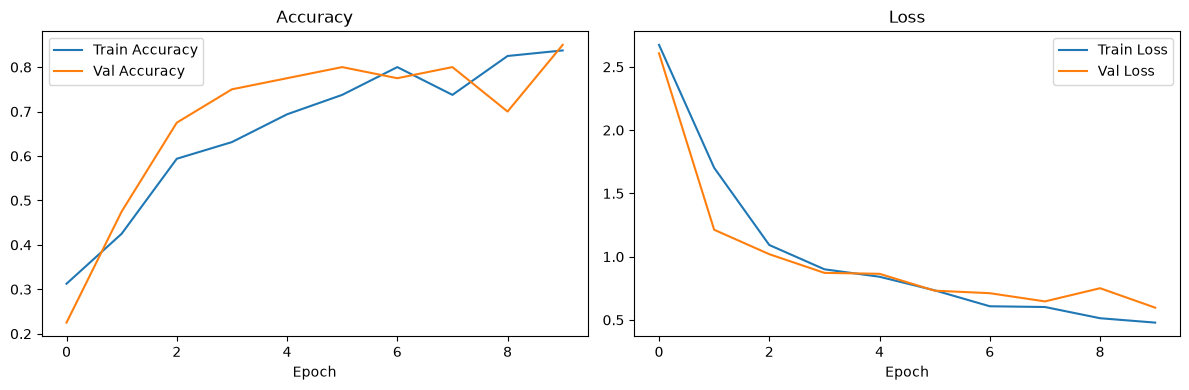

In [18]:
# Cell 12: Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("results_accuracy_loss.png")
plt.show()


In [19]:
# Cell 13: Save the trained model
model.save("vgg16_transfer_learning_model.h5")
print("Model saved successfully.")


Model saved successfully.
